# Team 08 - Mukhesh: real-image detector cache + Agent C (A2C)
**Part 1 needs Runtime -> Change runtime type -> T4 GPU.** Part 2 (Agent C) runs on CPU (fine in the same GPU session).

Before starting: `team08` folder must be in YOUR My Drive (Shared with me -> right-click team08 -> Organize -> Add shortcut -> My Drive).

## Step 1 - Mount, unpack, install

In [1]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/RL_Project/files_coding/For_Mukhesh'
# --- where each member's outputs live (shared by all notebooks) ---
ROOT  = '/content/drive/MyDrive/RL_Project/files_coding'
A_DIR = f'{ROOT}/uav_inspection'      # Agent A (DQN)  - Yeseswini
B_DIR = f'{ROOT}/For_Leekhith'        # Agent B (PPO)  - Leekhith
C_DIR = f'{ROOT}/For_Mukhesh'         # Agent C (A2C) + detector cache - Mukhesh
CACHE = f'{C_DIR}/detector_cache.npz' # real-image detector cache

!mkdir -p $DRIVE/results
!rm -rf /content/uav_inspection
!unzip -o -q $DRIVE/uav_inspection.zip -d /content/
%cd /content/uav_inspection
!pip install -q gymnasium stable-baselines3 tensorboard
!ls scripts

Mounted at /content/drive
/content/uav_inspection
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 11.2 MB/s eta 0:00:00
build_detector_cache.py  run_baselines.py  train_agent_a.py
_path.py		 run_full_mode.py  train_agent_b.py
__pycache__		 test_env.py	   train_agent_c.py


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 - Check GPU (should print Tesla T4)

In [ ]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


# PART 1 - Detector cache (real images)
## Step 3 - Download DeepCrack
Expected counts: 300 / 300 / 237 / 237

In [ ]:
!git clone -q --depth 1 https://github.com/yhlleo/DeepCrack.git /content/DeepCrack
!unzip -q -o /content/DeepCrack/dataset/DeepCrack.zip -d /content/deepcrack_data
import os
for d in ['train_img','train_lab','test_img','test_lab']: print(d, len(os.listdir(f'/content/deepcrack_data/{d}')))

train_img 300
train_lab 300
test_img 237
test_lab 237


## Step 4 - Train U-Net + build cache (~10 min on T4)
If Colab disconnects after training finished, re-run with `--reuse_model`.

In [ ]:
!python scripts/build_detector_cache.py --data /content/deepcrack_data --out $DRIVE

device: cuda
train images: 300   test images: 237
iter   400/4000  loss=0.6823
iter   800/4000  loss=0.4582
iter  1200/4000  loss=0.6720
iter  1600/4000  loss=0.3585
iter  2000/4000  loss=0.2373
iter  2400/4000  loss=0.2883
iter  2800/4000  loss=0.5585
iter  3200/4000  loss=0.4190
iter  3600/4000  loss=0.2932
iter  4000/4000  loss=0.3034
U-Net trained in 2.6 min
cache patches: 3000  (defect 1200, clean 1800)
q=0 ( 4px) done
q=1 ( 8px) done
q=2 (16px) done
q=3 (32px) done
q=4 (64px) done

 q  res | u defect  u clean | detect rate false pos | IoU defect
 0    4 |    0.601    0.321 |       0.398     0.009 |      0.193
 1    8 |    0.563    0.234 |       0.822     0.024 |      0.501
 2   16 |    0.543    0.179 |       0.927     0.048 |      0.644
 3   32 |    0.532    0.153 |       0.969     0.073 |      0.696
 4   64 |    0.526    0.140 |       0.982     0.125 |      0.717

raw monotonicity violations (before fusion): 50.6%

recommended success_unc for navigate mode: 0.282 (stored inside 

## Step 5 - Check the detector (your slide material)
Uncertainty must go DOWN and IoU UP from q0 to q4. Then tell the team the cache is in Drive.

,q,res,u_defect,u_clean,detect_rate,false_pos,iou_defect
0,0,4,0.601,0.321,0.398,0.009,0.193
1,1,8,0.563,0.234,0.822,0.024,0.501
2,2,16,0.543,0.179,0.928,0.048,0.644
3,3,32,0.532,0.153,0.969,0.073,0.696
4,4,64,0.526,0.140,0.982,0.125,0.717


success threshold: 0.282 | altitude->quality: [0, 1, 3]


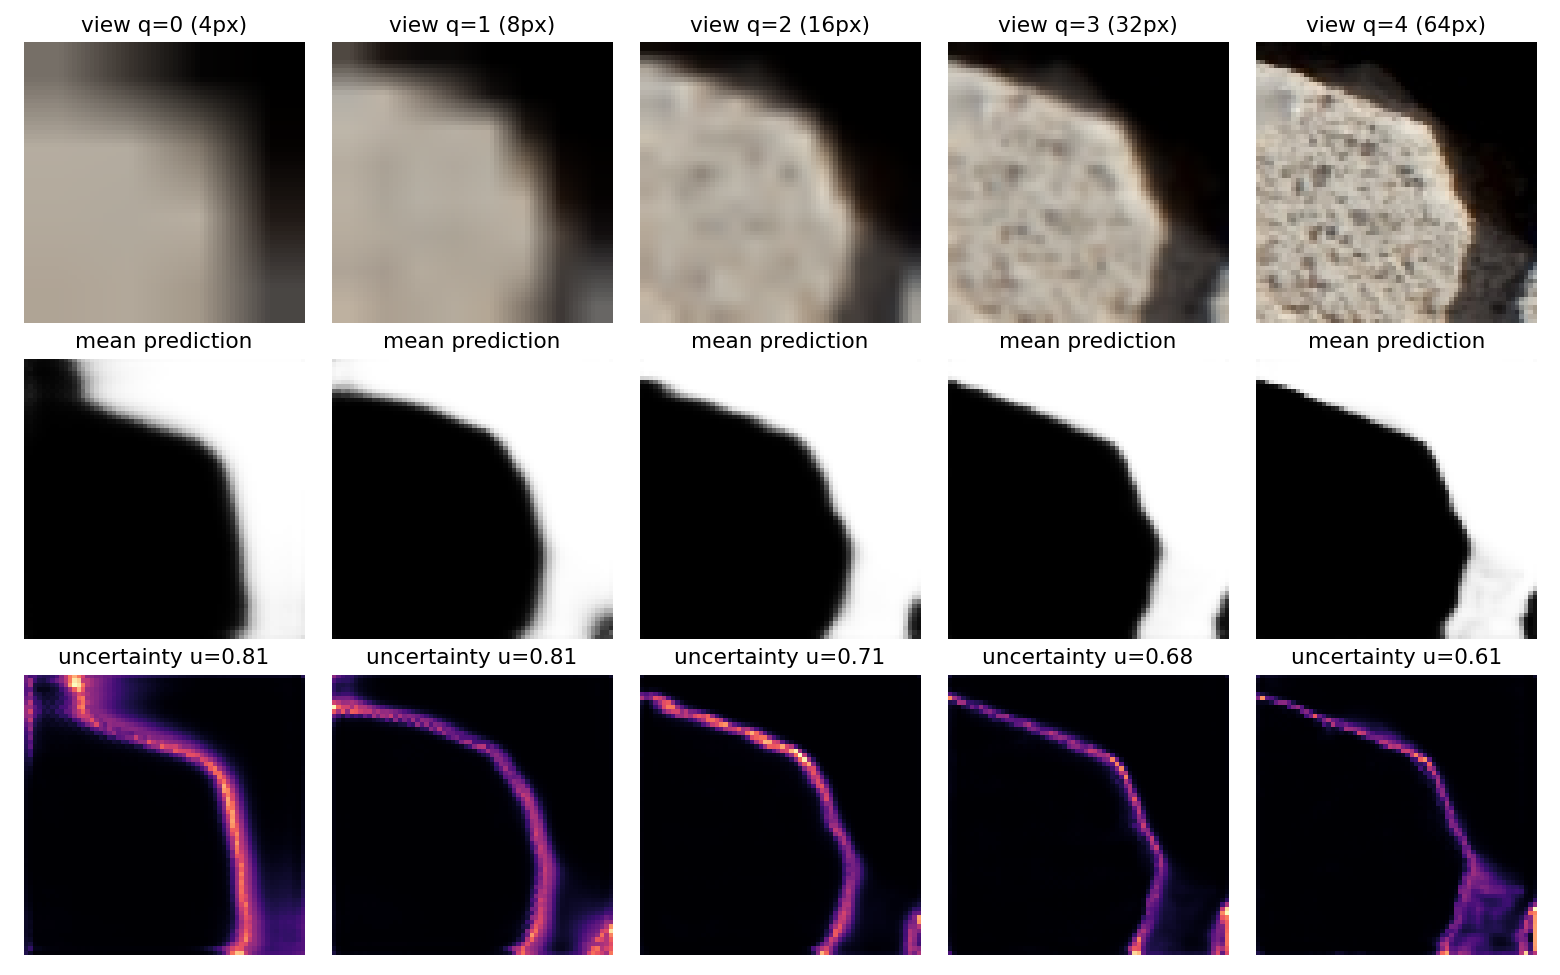

ALL TESTS PASSED


In [ ]:
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display
rep = json.load(open(f'{DRIVE}/detector_report.json'))
display(pd.DataFrame(rep['report']).round(3))
print('success threshold:', round(rep['success_unc'], 3), '| altitude->quality:', rep['alt_q'])
display(Image(f'{DRIVE}/detector_views.png'))
!python scripts/test_env.py | tail -1

# PART 2 - Agent C (A2C mission supervisor)
## Step 6 - Baselines (analytic)

In [ ]:
!python scripts/run_baselines.py --out $DRIVE/results


=== navigate (analytic) ===
random             return= -29.56±8.62  success=0.00  steps= 148.7  cov=0.51  unc=0.662  found=10.2/26  mIoU=0.244  energy=1.002
raster_mid         return=   6.20±0.07  success=0.00  steps= 199.0  cov=1.00  unc=0.351  found=20.9/26  mIoU=0.500  energy=1.000
raster_low         return=  35.43±0.09  success=1.00  steps= 123.0  cov=0.95  unc=0.219  found=23.5/26  mIoU=0.626  energy=0.625

=== refine (analytic) ===
random             return=  -2.24±0.17  success=0.00  steps=  30.0  cov=0.08  unc=0.963  found=1.1/26  mIoU=0.024  energy=0.240
fixed_orbit        return=  -2.29±0.08  success=0.00  steps=  30.0  cov=0.08  unc=0.963  found=1.1/26  mIoU=0.024  energy=0.240
scripted_approach  return=   5.68±0.16  success=1.00  steps=   3.5  cov=0.08  unc=0.961  found=1.2/26  mIoU=0.028  energy=0.028

=== supervise (analytic) ===
random             return=   4.07±9.13  success=1.00  steps=   3.0  cov=0.16  unc=0.903  found=3.0/26  mIoU=0.072  energy=0.066
rule_supervisor

## Step 7 - Train Agent C (~3-5 min)

In [ ]:
!python scripts/train_agent_c.py --steps 100000 --out $DRIVE/agentC

2026-09-26 18:22:23.645399: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Using cpu device
Logging to /content/drive/MyDrive/RL_Project/files_coding/For_Mukhesh/agentC/tb/A2C_1
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 30.2     |
|    ep_rew_mean        | 29.7     |
| time/                 |          |
|    fps                | 522

## Step 8 - Learning curves + results table

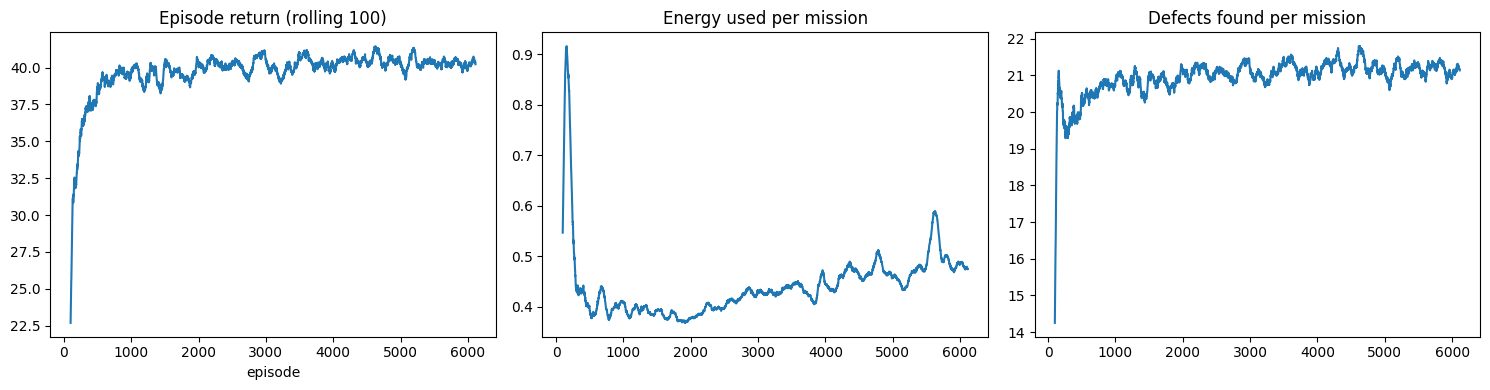

,policy,return_mean,success_mean,steps_mean,coverage_mean,defects_found_mean,miou_mean,energy_used_mean
0,A2C (Agent C),39.845,1.0,19.25,1.000,20.95,0.500,0.510
1,rule_supervisor,42.823,1.0,33.80,1.000,22.55,0.597,0.954
2,random,4.067,1.0,2.95,0.156,2.95,0.072,0.066


In [ ]:
import glob
df = pd.concat([pd.read_csv(f, skiprows=1) for f in glob.glob(f'{DRIVE}/agentC/monitor/*.monitor.csv')]).sort_values('t')
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(df['r'].rolling(100).mean().values); ax[0].set_title('Episode return (rolling 100)'); ax[0].set_xlabel('episode')
ax[1].plot(df['energy_used'].rolling(100).mean().values); ax[1].set_title('Energy used per mission')
ax[2].plot(df['defects_found'].rolling(100).mean().values); ax[2].set_title('Defects found per mission')
plt.tight_layout(); plt.savefig(f'{DRIVE}/agentC/learning_curves.png', dpi=150); plt.show()
pd.read_csv(f'{DRIVE}/agentC/agentC_vs_baselines.csv')[['policy','return_mean','success_mean','steps_mean','coverage_mean','defects_found_mean','miou_mean','energy_used_mean']].round(3)

## Step 9 - Live demo: state -> action probabilities -> option -> reward (CO3)

In [ ]:
import torch
from stable_baselines3 import A2C
from env import InspectionEnv
OPTS = ['Explore', 'Refine', 'Return home']
agent = A2C.load(f'{DRIVE}/agentC/best/best_model.zip', device='cpu')
env = InspectionEnv('supervise'); obs, info = env.reset(seed=1000)
for t in range(4):
    print(f'--- decision {t} | state [battery, coverage, mean_u, found, dist_home, time] = {np.round(obs, 2)}')
    with torch.no_grad():
        probs = agent.policy.get_distribution(agent.policy.obs_to_tensor(obs)[0]).distribution.probs[0].numpy()
    print('   policy pi(a|s):', {o: round(float(p), 2) for o, p in zip(OPTS, probs)})
    a = int(probs.argmax()); obs, r, term, trunc, info = env.step(a)
    print(f'   OPTION -> {OPTS[a]}   REWARD = {r:+.2f}   defects found = {info["defects_found"]}')
    if term or trunc: break

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


--- decision 0 | state [battery, coverage, mean_u, found, dist_home, time] = [1.   0.07 0.97 0.04 0.   0.  ]
   policy pi(a|s): {'Explore': 0.99, 'Refine': 0.01, 'Return home': 0.0}
   OPTION -> Explore   REWARD = +5.99   defects found = 4
--- decision 1 | state [battery, coverage, mean_u, found, dist_home, time] = [0.97 0.12 0.93 0.15 0.18 0.02]
   policy pi(a|s): {'Explore': 0.99, 'Refine': 0.01, 'Return home': 0.0}
   OPTION -> Explore   REWARD = +3.99   defects found = 6
--- decision 2 | state [battery, coverage, mean_u, found, dist_home, time] = [0.94 0.23 0.85 0.23 0.41 0.05]
   policy pi(a|s): {'Explore': 0.99, 'Refine': 0.01, 'Return home': 0.0}
   OPTION -> Explore   REWARD = +1.99   defects found = 7
--- decision 3 | state [battery, coverage, mean_u, found, dist_home, time] = [0.92 0.35 0.77 0.27 0.64 0.08]
   policy pi(a|s): {'Explore': 0.99, 'Refine': 0.01, 'Return home': 0.0}
   OPTION -> Explore   REWARD = +1.99   defects found = 8


## Step 10 - Exploration sensitivity: entropy coefficient (CO5, ~10 min)

In [ ]:
for ent in [0.0, 0.01, 0.05]:
    !python scripts/train_agent_c.py --steps 60000 --ent_coef {ent} --out $DRIVE/agentC_ent{ent}

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Using cpu device
Logging to /content/drive/MyDrive/RL_Project/files_coding/For_Mukhesh/agentC_ent0.0/tb/A2C_1
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 30.6     |
|    ep_rew_mean        | 29.1     |
| time/                 |          |
|    fps                | 439      |
|    iterations         | 100      |
|    time_elapsed       | 7        |
|    total_timesteps    | 3200     |
| train/                |          |
|    entropy_loss       | -0.19    |
|    explained_variance | 0.922    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    poli

In [ ]:
rows = []
for ent in [0.0, 0.01, 0.05]:
    r = pd.read_csv(f'{DRIVE}/agentC_ent{ent}/agentC_vs_baselines.csv').iloc[0]
    rows.append({'ent_coef': ent, 'return': round(r.return_mean, 2), 'energy': round(r.energy_used_mean, 3),
                 'defects_found': r.defects_found_mean, 'decisions': r.steps_mean})
pd.DataFrame(rows)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,ent_coef,return,energy,defects_found,decisions
0,0.00,39.92,0.350,20.95,13.15
1,0.01,40.86,0.475,21.45,17.75
2,0.05,40.49,0.424,21.25,16.45


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 11 (optional) - Agent C on real images, and with the trained Agent A inside 'explore'

In [2]:
!python scripts/train_agent_c.py --detector learned --cache $DRIVE/detector_cache.npz --out $DRIVE/agentC_learned
!python scripts/train_agent_c.py --nav_model $A_DIR/agentA/best/best_model.zip --out $DRIVE/agentC_withA

2026-09-27 07:39:27.009654: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Using cpu device
Logging to /content/drive/MyDrive/RL_Project/files_coding/For_Mukhesh/agentC_learned/tb/A2C_2
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 30.1     |
|    ep_rew_mean        | 31.2     |
| time/                 |          |
|    fps             